In [1]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from datetime import datetime
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from meteostat import Stations, Daily

In [2]:
demand_data = pd.read_csv('data/NGSD02.csv')
demand_data.head()

,STATISTIC,Statistic Label,TLIST(D1),Day,C04132V04898,Network Gas Customer Type,UNIT,VALUE
0,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,20,Non-Daily Metered (annual consumption < 5.55 GWh),Gigawatt hours,55.409405
1,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,30,Daily Metered (annual consumption >= 5.55 GWh ...,Gigawatt hours,7.251362
2,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,40,Large Daily Metered (annual metered capacity >...,Gigawatt hours,9.494423
3,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,10,Power Plants,Gigawatt hours,57.062501
4,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,-,All networked gas customers,Gigawatt hours,129.217691


In [3]:
demand_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12630 entries, 0 to 12629
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   STATISTIC                  12630 non-null  object 
 1   Statistic Label            12630 non-null  object 
 2   TLIST(D1)                  12630 non-null  object 
 3   Day                        12630 non-null  object 
 4   C04132V04898               12630 non-null  object 
 5   Network Gas Customer Type  12630 non-null  object 
 6   UNIT                       12630 non-null  object 
 7   VALUE                      12630 non-null  float64
dtypes: float64(1), object(7)
memory usage: 789.5+ KB


In [4]:
demand_data['Network Gas Customer Type'].value_counts()

Network Gas Customer Type
Non-Daily Metered (annual consumption < 5.55 GWh)                2526
Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)    2526
Large Daily Metered (annual metered capacity >= 57.5 GWh)        2526
Power Plants                                                     2526
All networked gas customers                                      2526
Name: count, dtype: int64

In [5]:
demand_data_pivoted = demand_data.pivot(index='Day', columns='Network Gas Customer Type', values='VALUE').reset_index()
demand_data_pivoted['DateTime'] = pd.to_datetime(demand_data_pivoted['Day'], format='%Y %B %d')
demand_data_pivoted = demand_data_pivoted.drop(columns=['Day'])
demand_data_pivoted = demand_data_pivoted.reset_index(drop=True)

demand_data_pivoted.head()

Network Gas Customer Type,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05


In [6]:
demand_data_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 6 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   All networked gas customers                                    2526 non-null   float64       
 1   Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)  2526 non-null   float64       
 2   Large Daily Metered (annual metered capacity >= 57.5 GWh)      2526 non-null   float64       
 3   Non-Daily Metered (annual consumption < 5.55 GWh)              2526 non-null   float64       
 4   Power Plants                                                   2526 non-null   float64       
 5   DateTime                                                       2526 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 118.5 KB


In [7]:
supply_data = pd.read_csv('data/NGSD01.csv')
supply_data.head()

,STATISTIC,Statistic Label,TLIST(D1),Day,C04236V05009,Supply Type,UNIT,VALUE
0,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,-,All networked gas supply,Gigawatt hours,129.217691
1,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,10,Networked gas supply - indigenous production,Gigawatt hours,111.682190
2,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,20,Networked gas supply - imports,Gigawatt hours,17.535501
3,NGSD01C01,Networked Gas Daily Supply,2018M01D02,2018 January 02,-,All networked gas supply,Gigawatt hours,132.580714
4,NGSD01C01,Networked Gas Daily Supply,2018M01D02,2018 January 02,10,Networked gas supply - indigenous production,Gigawatt hours,115.101624


In [8]:
supply_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7578 entries, 0 to 7577
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   STATISTIC        7578 non-null   object 
 1   Statistic Label  7578 non-null   object 
 2   TLIST(D1)        7578 non-null   object 
 3   Day              7578 non-null   object 
 4   C04236V05009     7578 non-null   object 
 5   Supply Type      7578 non-null   object 
 6   UNIT             7578 non-null   object 
 7   VALUE            7578 non-null   float64
dtypes: float64(1), object(7)
memory usage: 473.8+ KB


In [9]:
supply_data_pivoted = supply_data.pivot(index='Day', columns='Supply Type', values='VALUE').reset_index()
supply_data_pivoted['DateTime'] = pd.to_datetime(supply_data_pivoted['Day'], format='%Y %B %d')
supply_data_pivoted = supply_data_pivoted.drop(columns=['Day'])
supply_data_pivoted = supply_data_pivoted.reset_index(drop=True)

supply_data_pivoted.head()

Supply Type,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production,DateTime
0,146.711805,39.291462,107.420343,2018-04-01
1,165.611510,60.055502,105.556008,2018-04-02
2,167.741525,60.435102,107.306423,2018-04-03
3,173.564111,66.254217,107.309894,2018-04-04
4,144.059799,36.725712,107.334087,2018-04-05


In [10]:
# merge these two dfs

merged_data = pd.merge(demand_data_pivoted, supply_data_pivoted, on='DateTime', how='left')
merged_data.head()

,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01,146.711805,39.291462,107.420343
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02,165.611510,60.055502,105.556008
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03,167.741525,60.435102,107.306423
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04,173.564111,66.254217,107.309894
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05,144.059799,36.725712,107.334087


In [11]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 9 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   All networked gas customers                                    2526 non-null   float64       
 1   Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)  2526 non-null   float64       
 2   Large Daily Metered (annual metered capacity >= 57.5 GWh)      2526 non-null   float64       
 3   Non-Daily Metered (annual consumption < 5.55 GWh)              2526 non-null   float64       
 4   Power Plants                                                   2526 non-null   float64       
 5   DateTime                                                       2526 non-null   datetime64[ns]
 6   All networked gas supply                                       2526 non-null   float64       
 7 

In [12]:
merged_data['Date'] = merged_data['DateTime'].dt.date.astype('str')
merged_data.head()

,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production,Date
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01,146.711805,39.291462,107.420343,2018-04-01
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02,165.611510,60.055502,105.556008,2018-04-02
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03,167.741525,60.435102,107.306423,2018-04-03
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04,173.564111,66.254217,107.309894,2018-04-04
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05,144.059799,36.725712,107.334087,2018-04-05


In [13]:
merged_data = merged_data.rename(columns={
    'DateTime': 'date_time',
    'Date': 'date',
    'All networked gas customers': 'total_demand',
    'Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)': 'small_metered_demand',
    'Large Daily Metered (annual metered capacity >= 57.5 GWh)': 'large_metered_demand',
    'Non-Daily Metered (annual consumption < 5.55 GWh)': 'non_metered_demand',
    'Power Plants': 'power_plant_demand',
    'All networked gas supply': 'total_supply',
    'Networked gas supply - imports': 'imported_supply',
    'Networked gas supply - indigenous production': 'local_supply'
})

merged_data = merged_data[['date_time', 'date', 'imported_supply', 'local_supply', 'total_supply', 'non_metered_demand', 'small_metered_demand', 'large_metered_demand', 'power_plant_demand', 'total_demand']]
merged_data['supply_demand_diff'] = merged_data['total_supply'] - merged_data['total_demand']

merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0


In [14]:
merged_data.describe()

,date_time,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff
count,2526,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000
mean,2021-06-16 12:00:00,98.133096,54.201660,152.334756,31.294291,9.058458,16.164441,95.876216,152.393407,-0.058651
min,2018-01-01 00:00:00,0.121983,0.000000,71.447572,6.534082,4.375607,5.119280,36.554999,71.685350,-0.381877
25%,2019-09-24 06:00:00,73.269391,35.321917,132.635175,12.846622,7.722517,14.847689,78.318750,132.694342,-0.118264
50%,2021-06-16 12:00:00,96.544000,47.090939,151.655414,28.869508,8.835984,16.361759,96.825695,151.754277,0.000000
75%,2023-03-09 18:00:00,120.149258,73.812488,171.018348,47.417615,10.479090,17.771905,113.533403,171.018348,0.000000
max,2024-11-30 00:00:00,223.458938,117.938242,261.326100,97.227563,14.030331,21.967155,167.389168,261.448600,0.000000
std,NaN,35.164032,25.222567,29.642927,18.746416,1.857509,2.376663,24.301787,29.629737,0.076150


In [15]:
start_date = merged_data['date_time'].min()
end_date = merged_data['date_time'].max()

In [16]:
merged_data.isna().sum()

date_time               0
date                    0
imported_supply         0
local_supply            0
total_supply            0
non_metered_demand      0
small_metered_demand    0
large_metered_demand    0
power_plant_demand      0
total_demand            0
supply_demand_diff      0
dtype: int64

In [17]:
stations = Stations()
temparature_df = pd.DataFrame()

ireland_stations = stations.region('IE') # weather stations in ireland region
ireland_stations = ireland_stations.inventory('daily', start_date)

ireland_stations_count = ireland_stations.count()
ireland_stations_all = ireland_stations.fetch(ireland_stations_count)

for id, row in ireland_stations_all.iterrows():
    daily = Daily(id, start_date, end_date)
    daily_temparature_data = daily.fetch()
    temparature_df[row['name']] = daily_temparature_data['tavg']

temparature_df.head()

,Valentia Observatory,Cork Airport,Johnstown Castle / Ballykilliane,Shannon Airport,Casement Aerodrome,Dublin Airport,Connaught Airport,Belmullet,Malin Head
time,,,,,,,,,
2018-01-01,8.6,5.5,5.9,6.6,4.9,5.2,4.4,7.7,6.7
2018-01-02,10.0,8.3,8.4,8.2,7.4,7.3,5.2,7.7,6.2
2018-01-03,8.8,6.6,7.1,8.1,6.2,6.6,6.2,8.6,7.8
2018-01-04,8.0,7.1,7.2,7.3,5.8,5.6,3.6,6.4,5.8
2018-01-05,5.5,3.6,3.9,5.3,3.3,3.2,2.5,6.3,4.8


In [18]:
temparature_df.isnull().sum()

Valentia Observatory                0
Cork Airport                        0
Johnstown Castle / Ballykilliane    9
Shannon Airport                     0
Casement Aerodrome                  0
Dublin Airport                      0
Connaught Airport                   0
Belmullet                           0
Malin Head                          0
dtype: int64

In [19]:
missing_dates = temparature_df[temparature_df['Johnstown Castle / Ballykilliane'].isnull()].index
missing_dates

DatetimeIndex(['2018-09-17', '2024-08-28', '2024-08-29', '2024-08-30',
               '2024-08-31', '2024-09-01', '2024-09-02', '2024-09-03',
               '2024-09-04'],
              dtype='datetime64[ns]', name='time', freq=None)

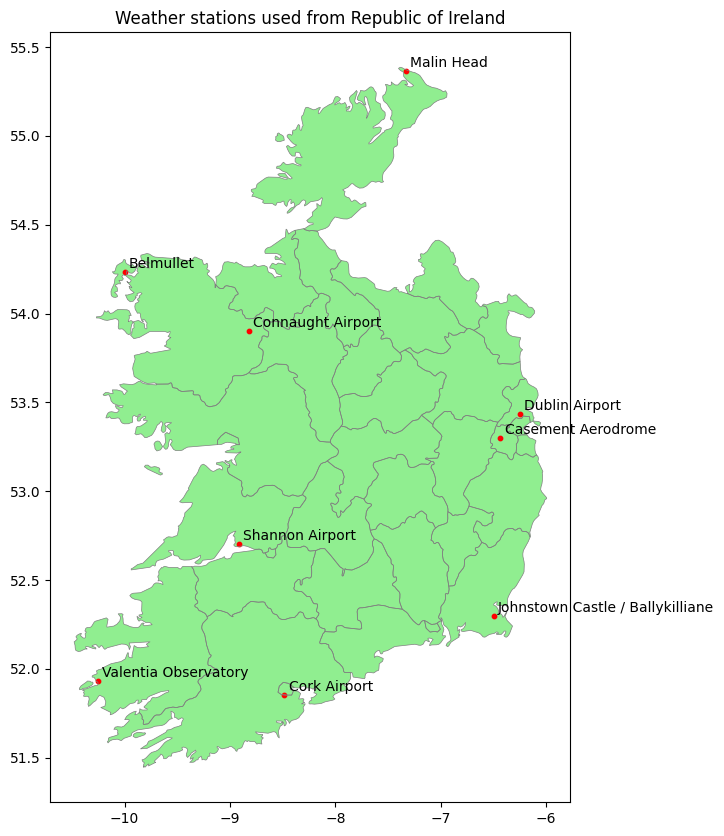

In [20]:
stations_gdf = gpd.GeoDataFrame(
    ireland_stations_all,
    geometry=gpd.points_from_xy(ireland_stations_all.longitude, ireland_stations_all.latitude),
    crs="EPSG:4326"  # WGS84 coordinate reference system (lat/lon)
)

world = gpd.read_file(f'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries.geojson')
ireland = world[world['ISO_A3'] == 'IRL']

admin1 = gpd.read_file('https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_1_states_provinces.geojson')
ireland_counties = admin1[admin1['adm0_a3'] == 'IRL']

fig, ax = plt.subplots(figsize=(10, 10))
ireland.plot(ax=ax, color='lightgreen', edgecolor='none')
ireland_counties.boundary.plot(ax=ax, color='grey', linewidth=0.5)
stations_gdf.plot(ax=ax, color='red', markersize=10)
ax.set_title('Weather stations used from Republic of Ireland')

for x, y, label in zip(stations_gdf.geometry.x, stations_gdf.geometry.y, stations_gdf['name']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")

In [21]:
# to populate missing values, we will take avg of temperature of nearby locations

nearby_locations = ['Valentia Observatory', 'Cork Airport', 'Shannon Airport', 'Dublin Airport', 'Casement Aerodrome']
temparature_df.loc[missing_dates, nearby_locations]
avg_temp_nearby = temparature_df.loc[missing_dates, nearby_locations].mean(axis=1)
temparature_df.loc[missing_dates, 'Johnstown Castle / Ballykilliane'] = avg_temp_nearby

temparature_df.isnull().sum()

Valentia Observatory                0
Cork Airport                        0
Johnstown Castle / Ballykilliane    0
Shannon Airport                     0
Casement Aerodrome                  0
Dublin Airport                      0
Connaught Airport                   0
Belmullet                           0
Malin Head                          0
dtype: int64

In [22]:
temparature_df['temperature_c'] = temparature_df.mean(axis=1).round(2)
temparature_df['date_time'] = temparature_df.index
temparature_df['date_time'] = pd.to_datetime(temparature_df['date_time'])
temparature_df = temparature_df.reset_index(drop=True)
temparature_df

,Valentia Observatory,Cork Airport,Johnstown Castle / Ballykilliane,Shannon Airport,Casement Aerodrome,Dublin Airport,Connaught Airport,Belmullet,Malin Head,temperature_c,date_time
0,8.6,5.5,5.9,6.6,4.9,5.2,4.4,7.7,6.7,6.17,2018-01-01
1,10.0,8.3,8.4,8.2,7.4,7.3,5.2,7.7,6.2,7.63,2018-01-02
2,8.8,6.6,7.1,8.1,6.2,6.6,6.2,8.6,7.8,7.33,2018-01-03
3,8.0,7.1,7.2,7.3,5.8,5.6,3.6,6.4,5.8,6.31,2018-01-04
4,5.5,3.6,3.9,5.3,3.3,3.2,2.5,6.3,4.8,4.27,2018-01-05
...,...,...,...,...,...,...,...,...,...,...,...
2521,5.1,4.5,4.7,3.4,3.6,2.9,2.8,4.7,5.9,4.18,2024-11-26
2522,4.7,3.8,4.8,-0.7,0.6,1.0,2.3,2.1,3.6,2.47,2024-11-27
2523,12.5,9.8,9.3,8.8,6.7,5.5,4.5,7.3,5.8,7.80,2024-11-28
2524,13.7,12.0,12.7,13.3,13.2,12.2,11.2,11.2,12.8,12.48,2024-11-29


In [23]:
def get_season(datetime):
    month = datetime.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return np.nan


climate_df = temparature_df[['date_time', 'temperature_c']].copy()
climate_df['season'] = climate_df['date_time'].apply(get_season)
climate_df.head()

,date_time,temperature_c,season
0,2018-01-01,6.17,Winter
1,2018-01-02,7.63,Winter
2,2018-01-03,7.33,Winter
3,2018-01-04,6.31,Winter
4,2018-01-05,4.27,Winter


In [24]:
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date_time      2526 non-null   datetime64[ns]
 1   temperature_c  2526 non-null   float64       
 2   season         2526 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 59.3+ KB


In [25]:
# merge climate_df with merged_data

merged_data = pd.merge(merged_data, climate_df, on='date_time', how='left')
merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff,temperature_c,season
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0,4.20,Spring
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0,5.50,Spring
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0,7.12,Spring
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0,5.31,Spring
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0,5.33,Spring


In [26]:
def fetch_irish_holidays(url):
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    soup = BeautifulSoup(response.content, 'html.parser')
    rows = soup.find_all('tr', attrs={'data-date': True})

    data = []
    for row in rows:
        try:
            timestamp = int(row['data-date']) // 1000
            date = datetime.utcfromtimestamp(timestamp).date()
            cols = row.find_all('td')
            if len(cols) >= 2:
                name = cols[1].text.strip()
                holiday_type = cols[2].text.strip() if len(cols) > 2 else np.nan
                holiday_status = 'Yes' if holiday_type == 'National Holiday' else 'No'
                data.append({'date_time': date, 'name': name, 'type': holiday_type, 'holiday_status': holiday_status})
        except Exception as e:
            print(f"Error parsing row: {e}")
            continue

    return pd.DataFrame(data)

In [27]:
holidays_df = pd.DataFrame(columns=['date_time', 'name', 'type', 'holiday_status'])

for year in range(start_date.year, end_date.year + 1):
    url = f"https://www.timeanddate.com/holidays/ireland/{year}"
    df_year = fetch_irish_holidays(url)
    df_year['date_time'] = pd.to_datetime(df_year['date_time'])
    df_year['date'] = df_year['date_time'].dt.date
    holidays_df = pd.concat([holidays_df, df_year], ignore_index=True)

holidays_df = holidays_df.sort_values(by='date_time')
# holidays_df = holidays_df[['DateTime', 'Date', 'Name', 'Type', 'Holiday Status']]
holidays_df.head()

,date_time,name,type,holiday_status,date
0,2018-01-01,New Year's Day,National Holiday,Yes,2018-01-01
1,2018-01-06,Epiphany,Observance,No,2018-01-06
2,2018-03-11,Mother's Day,Observance,No,2018-03-11
3,2018-03-17,St. Patrick's Day,National Holiday,Yes,2018-03-17
4,2018-03-20,March Equinox,Season,No,2018-03-20


In [28]:
holidays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_time       188 non-null    datetime64[ns]
 1   name            188 non-null    object        
 2   type            188 non-null    object        
 3   holiday_status  188 non-null    object        
 4   date            188 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 7.5+ KB


In [29]:
holidays_hash = {}
for index, row in holidays_df.iterrows():
    holidays_hash[str(row['date'])] = row['holiday_status']

merged_data['holiday_status'] = merged_data['date'].apply(lambda x: holidays_hash.get(x, 'No'))
merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff,temperature_c,season,holiday_status
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0,4.20,Spring,No
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0,5.50,Spring,Yes
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0,7.12,Spring,No
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0,5.31,Spring,No
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0,5.33,Spring,No


In [30]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date_time             2526 non-null   datetime64[ns]
 1   date                  2526 non-null   object        
 2   imported_supply       2526 non-null   float64       
 3   local_supply          2526 non-null   float64       
 4   total_supply          2526 non-null   float64       
 5   non_metered_demand    2526 non-null   float64       
 6   small_metered_demand  2526 non-null   float64       
 7   large_metered_demand  2526 non-null   float64       
 8   power_plant_demand    2526 non-null   float64       
 9   total_demand          2526 non-null   float64       
 10  supply_demand_diff    2526 non-null   float64       
 11  temperature_c         2526 non-null   float64       
 12  season                2526 non-null   object        
 13  holiday_status    

In [31]:
final_df = merged_data.copy()
final_df.to_csv('data/final_df.csv', index=False)